In [1]:
import pandas as pd
import seaborn as srn
import statistics as sts
import numpy as np
import matplotlib.pyplot as plt
import difflib

In [2]:
#importando a planilha
from google.colab import files
upload = files.upload()

Saving Campe_Supply_Corrompido.xlsx - Campe Supply.csv to Campe_Supply_Corrompido.xlsx - Campe Supply.csv


In [3]:
#importar dados
dataset = pd.read_csv("Campe_Supply_Corrompido.xlsx - Campe Supply.csv", sep=",", index_col=0)
#carregando o arquivo
dataset = pd.read_csv("Campe_Supply_Corrompido.xlsx - Campe Supply.csv", index_col=False)
#visualizando a planilha
dataset.head()

,UNNAMED: 0,data da venda,SETOR,PRODUTO,VENDEDOR,região,ESTADO,cliente,FATURAMENTO,margem de lucro,LUCRO,coluna_inutil_0,coluna_inutil_1
0,NaN,2035-01-01 00:00:00,Carnes,kuína,Amaral,Sudeste,Minas Gerais,Atacado,"633,45","0,13","82,3485",PvlTk,SvWK1
1,NaN,2035-01-01 00:00:00,Latícinio,Queijo,Leo,Sudeste,Minas Gerais,Atacarejo,"611,4","0,07","42,798",4ZBrt,gwduN
2,NaN,2035-01-01 00:00:00,Congelados,Sorvete,Leo,Nordeste,NaN,Atacarejo,"721,52","0,08",NaN,Mc6m1,NFY0g
3,NaN,2035-01-01 00:00:00,Carnes,Bovina,Daniele,Sudeste,São Paulo,Atacado,"679,39",0.09,"61,1451",ROb74,QDXmd
4,NaN,2035-01-01 00:00:00,Carnes,Frango,Vanessa,Sul,Rio Grande do Sul,tarejo,964.52,"0,19","183,2588",n8NR2,Ml1t1


In [4]:
#Verificando formato
dataset.shape

(1690, 13)

#TRATAMENTO DE DADOS

In [5]:
#Removendo colunas inuteis
indices_para_remover = [0,11, 12]

dataset.drop(columns=dataset.columns[indices_para_remover], inplace= True)

dataset.head()

,data da venda,SETOR,PRODUTO,VENDEDOR,região,ESTADO,cliente,FATURAMENTO,margem de lucro,LUCRO
0,2035-01-01 00:00:00,Carnes,kuína,Amaral,Sudeste,Minas Gerais,Atacado,"633,45","0,13","82,3485"
1,2035-01-01 00:00:00,Latícinio,Queijo,Leo,Sudeste,Minas Gerais,Atacarejo,"611,4","0,07","42,798"
2,2035-01-01 00:00:00,Congelados,Sorvete,Leo,Nordeste,NaN,Atacarejo,"721,52","0,08",NaN
3,2035-01-01 00:00:00,Carnes,Bovina,Daniele,Sudeste,São Paulo,Atacado,"679,39",0.09,"61,1451"
4,2035-01-01 00:00:00,Carnes,Frango,Vanessa,Sul,Rio Grande do Sul,tarejo,964.52,"0,19","183,2588"


In [6]:
#Padronizando o nome das colunas
dataset.columns = ["Data_Da_Venda", "Setor", "Produto", "Vendedor", "Região", "Estado", "Cliente", "Faturamento", "Margem_De_Lucro","Lucro"]

dataset.head()

,Data_Da_Venda,Setor,Produto,Vendedor,Região,Estado,Cliente,Faturamento,Margem_De_Lucro,Lucro
0,2035-01-01 00:00:00,Carnes,kuína,Amaral,Sudeste,Minas Gerais,Atacado,"633,45","0,13","82,3485"
1,2035-01-01 00:00:00,Latícinio,Queijo,Leo,Sudeste,Minas Gerais,Atacarejo,"611,4","0,07","42,798"
2,2035-01-01 00:00:00,Congelados,Sorvete,Leo,Nordeste,NaN,Atacarejo,"721,52","0,08",NaN
3,2035-01-01 00:00:00,Carnes,Bovina,Daniele,Sudeste,São Paulo,Atacado,"679,39",0.09,"61,1451"
4,2035-01-01 00:00:00,Carnes,Frango,Vanessa,Sul,Rio Grande do Sul,tarejo,964.52,"0,19","183,2588"


##Corrigindo os formatos de dado: Data_Da_Venda, Faturamento, Magem_De_Lucro e Lucro




###Ajeitando Data_Da_Venda

In [7]:
#Analise Exploratoria de Data_Da_Venda
dataset["Data_Da_Venda"].describe()


,Data_Da_Venda
count,1606
unique,358
top,2035-01-31 00:00:00
freq,11


In [8]:
#Transformando o tipo em Data_Da_Venda
dataset["Data_Da_Venda"] = pd.to_datetime(dataset["Data_Da_Venda"], errors='coerce')

dataset.head(25)

,Data_Da_Venda,Setor,Produto,Vendedor,Região,Estado,Cliente,Faturamento,Margem_De_Lucro,Lucro
0,2035-01-01,Carnes,kuína,Amaral,Sudeste,Minas Gerais,Atacado,"633,45","0,13","82,3485"
1,2035-01-01,Latícinio,Queijo,Leo,Sudeste,Minas Gerais,Atacarejo,"611,4","0,07","42,798"
2,2035-01-01,Congelados,Sorvete,Leo,Nordeste,NaN,Atacarejo,"721,52","0,08",NaN
3,2035-01-01,Carnes,Bovina,Daniele,Sudeste,São Paulo,Atacado,"679,39",0.09,"61,1451"
4,2035-01-01,Carnes,Frango,Vanessa,Sul,Rio Grande do Sul,tarejo,964.52,"0,19","183,2588"
5,2035-01-01,Latícinio,Coalhada,Leo,Nordeste,Rio Grande do Norte,Attcarejo,"565,7","0,08","45,256"
6,2035-01-01,Cvrnes,Frango,Vanessa,Nordeste,Rio Grande do Norte,Atacarejo,"721,01",0.05,"36,0505"
7,2035-01-01,Carnes,Bovina,Vanessa,Sul,Rio Grande do Sul,Atacado,"649,4",0.11,"71,434"
8,2035-01-02,Latícinio,Coalhada,NaN,Sudeste,Minas Gerais,Atacarejo,"789,01","0,19",149.9119
9,NaT,Latícinio,Queijo,Daniele,Nordeste,Bahia,Atacado,"574,3","0,05","28,715"


In [9]:
#Prenchendo os espaços vazios de Data_Da_Venda
dataset['Data_Da_Venda'] = dataset['Data_Da_Venda'].ffill() #usado os valores a cima, visto que a lista estava ordenada por ordem a cronologica
dataset.head(25)


,Data_Da_Venda,Setor,Produto,Vendedor,Região,Estado,Cliente,Faturamento,Margem_De_Lucro,Lucro
0,2035-01-01,Carnes,kuína,Amaral,Sudeste,Minas Gerais,Atacado,"633,45","0,13","82,3485"
1,2035-01-01,Latícinio,Queijo,Leo,Sudeste,Minas Gerais,Atacarejo,"611,4","0,07","42,798"
2,2035-01-01,Congelados,Sorvete,Leo,Nordeste,NaN,Atacarejo,"721,52","0,08",NaN
3,2035-01-01,Carnes,Bovina,Daniele,Sudeste,São Paulo,Atacado,"679,39",0.09,"61,1451"
4,2035-01-01,Carnes,Frango,Vanessa,Sul,Rio Grande do Sul,tarejo,964.52,"0,19","183,2588"
5,2035-01-01,Latícinio,Coalhada,Leo,Nordeste,Rio Grande do Norte,Attcarejo,"565,7","0,08","45,256"
6,2035-01-01,Cvrnes,Frango,Vanessa,Nordeste,Rio Grande do Norte,Atacarejo,"721,01",0.05,"36,0505"
7,2035-01-01,Carnes,Bovina,Vanessa,Sul,Rio Grande do Sul,Atacado,"649,4",0.11,"71,434"
8,2035-01-02,Latícinio,Coalhada,NaN,Sudeste,Minas Gerais,Atacarejo,"789,01","0,19",149.9119
9,2035-01-02,Latícinio,Queijo,Daniele,Nordeste,Bahia,Atacado,"574,3","0,05","28,715"


###Ajeitada os valores de Faturamento, Magem_De_Lucro e Lucro

In [10]:
#Trasnformando o tipo de dado de Faturamento, Margem_De_Lucro e Lucro
colunas_para_converter = ["Faturamento", "Margem_De_Lucro", "Lucro"]

def converter_para_float_e_arredondar(series):
  cleaned_series = series.astype(str).str.replace(',', '.', regex=False)
  numeric_series = pd.to_numeric(cleaned_series, errors='coerce')
  numeric_series = numeric_series[numeric_series < 1e6] #nos meses 3 e 11 foram observados numeros descrepantes, assim foram desconsiderados
  rounded_series = numeric_series.round(2)
  return rounded_series

for coluna in colunas_para_converter:
  dataset[coluna] = converter_para_float_e_arredondar(dataset[coluna])

dataset.head(309)


,Data_Da_Venda,Setor,Produto,Vendedor,Região,Estado,Cliente,Faturamento,Margem_De_Lucro,Lucro
0,2035-01-01,Carnes,kuína,Amaral,Sudeste,Minas Gerais,Atacado,633.45,0.13,82.35
1,2035-01-01,Latícinio,Queijo,Leo,Sudeste,Minas Gerais,Atacarejo,611.40,0.07,42.80
2,2035-01-01,Congelados,Sorvete,Leo,Nordeste,NaN,Atacarejo,721.52,0.08,NaN
3,2035-01-01,Carnes,Bovina,Daniele,Sudeste,São Paulo,Atacado,679.39,0.09,61.15
4,2035-01-01,Carnes,Frango,Vanessa,Sul,Rio Grande do Sul,tarejo,964.52,0.19,183.26
...,...,...,...,...,...,...,...,...,...,...
304,2035-03-17,NaN,Suwna,wmaral,NaN,Paraná,Atacarejo,1192.84,0.17,NaN
305,2035-03-17,Bebidas,Sucos,Evandro,Nordeste,Rio Grande do Norte,Varejo,1146.71,0.18,206.41
306,2035-03-17,Bebidas,NaN,Leo,Sudeste,São Paulo,Atacado,1256.90,0.06,75.41
307,2035-03-18,Carnes,Bovina,Evandro,Sul,Rio Grande do Sul,Varejo,1128.34,0.08,90.27


In [11]:
#Preenchendo os espaços vazios de Faturamento, Margem_De_Lucro e Lucro

#Excluindo linhas com mais de dois espaços vazios
nan_count = dataset[colunas_para_converter].isnull().sum(axis=1)
dataset = dataset[nan_count <= 2].copy()

#Preenchendo os espaços vazios de Faturamento, Margem_De_Lucro e Lucro
def preenchendo_espacos_vazios(row):
  faturamento, margem_de_lucro, lucro = row['Faturamento'], row['Margem_De_Lucro'], row['Lucro']

  #Faturamento faltando
  if pd.isna(faturamento) and not pd.isna(margem_de_lucro) and not pd.isna(lucro):
    if margem_de_lucro != 0:
      row['Faturamento'] = lucro / margem_de_lucro

  #Margem de lucro faltando
  elif pd.isna(margem_de_lucro) and not pd.isna(faturamento) and not pd.isna(lucro):
    if faturamento != 0:
      row['Margem_De_Lucro'] = lucro / faturamento

  #Lucro faltando
  elif pd.isna(lucro) and not pd.isna(faturamento) and not pd.isna(margem_de_lucro):
    row['Lucro'] = faturamento * margem_de_lucro

  # Arredonda novamente após os cálculos
  row['Faturamento'] = round(row['Faturamento'], 2)
  row['Margem_De_Lucro'] = round(row['Margem_De_Lucro'], 2)
  row['Lucro'] = round(row['Lucro'], 2)

  return row

dataset = dataset.apply(preenchendo_espacos_vazios, axis=1)
dataset.head(60)

,Data_Da_Venda,Setor,Produto,Vendedor,Região,Estado,Cliente,Faturamento,Margem_De_Lucro,Lucro
0,2035-01-01,Carnes,kuína,Amaral,Sudeste,Minas Gerais,Atacado,633.45,0.13,82.35
1,2035-01-01,Latícinio,Queijo,Leo,Sudeste,Minas Gerais,Atacarejo,611.40,0.07,42.80
2,2035-01-01,Congelados,Sorvete,Leo,Nordeste,NaN,Atacarejo,721.52,0.08,57.72
3,2035-01-01,Carnes,Bovina,Daniele,Sudeste,São Paulo,Atacado,679.39,0.09,61.15
4,2035-01-01,Carnes,Frango,Vanessa,Sul,Rio Grande do Sul,tarejo,964.52,0.19,183.26
5,2035-01-01,Latícinio,Coalhada,Leo,Nordeste,Rio Grande do Norte,Attcarejo,565.70,0.08,45.26
6,2035-01-01,Cvrnes,Frango,Vanessa,Nordeste,Rio Grande do Norte,Atacarejo,721.01,0.05,36.05
7,2035-01-01,Carnes,Bovina,Vanessa,Sul,Rio Grande do Sul,Atacado,649.40,0.11,71.43
8,2035-01-02,Latícinio,Coalhada,NaN,Sudeste,Minas Gerais,Atacarejo,789.01,0.19,149.91
9,2035-01-02,Latícinio,Queijo,Daniele,Nordeste,Bahia,Atacado,574.30,0.05,28.72


##Ajeitando o restante das colunas

###Setor e Produto

In [12]:
#Analise exploratoria de Setor
agrupado = dataset.groupby(["Setor"]).size()
agrupado

,0
Setor,
Bebadas,1
Bebedas,1
Bebiaas,1
Bebicas,1
Bebidas,361
...,...
tarnes,1
tebidas,1
tongelados,1


Tipos achados: Congelados, laticinios, carnes e bebidas

In [13]:
setores_validos = ["Congelados", "Laticínios", "Carnes", "Bebidas"]

def corrigir_setor(setor):
  if pd.isna(setor): # Check for NaN values
    return "Indefinido"
  match = difflib.get_close_matches(setor, setores_validos, n=1, cutoff=0.6)
  return match[0] if match else setor


dataset["Setor"] = dataset["Setor"].apply(corrigir_setor)


#Analisando os dados agroa corrigidos
agrupado = dataset.groupby(["Setor"]).size()
agrupado

,0
Setor,
Bebidas,401
Carnes,392
Congelados,402
Indefinido,86
Laticínios,408


In [14]:
#Analise Exploratoria da coluna Produto
agrupado = dataset.groupby(["Produto"]).size()
agrupado

,0
Produto,
Bhvina,2
Bobina,1
Booina,1
Botina,1
Bovika,1
...,...
xueijo,1
xuína,1
yorvete,1


Percebe-se o mesmo erro do que com setores, nome de produtos encontrados: "Sorvete, Bovina, Suina, Queijo, Cerveja,Frango, Refrigerante, Leite, Lasanha, Pizza, Suco, Coalhada"

In [15]:
produtos_validos = ["Sorvete", "Bovina", "Suina", "Queijo", "Cerveja", "Frango", "Refrigerante", "Leite", "Lasanha", "Pizza", "Suco", "Coalhada"]

def corrigir_produto(produto):
  if pd.isna(produto): # Check for NaN values
    return "Indefinido"
  match = difflib.get_close_matches(produto, produtos_validos, n=1, cutoff=0.6)
  return match[0] if match else produto


dataset["Produto"] = dataset["Produto"].apply(corrigir_produto)


#Analisando os dados agroa corrigidos
agrupado = dataset.groupby(["Produto"]).size()
agrupado

,0
Produto,
Bovina,153
Cerveja,169
Coalhada,21
Frango,169
Indefinido,83
Lasanha,85
Leite,139
Pizza,79
Queijo,236


In [16]:
#Completar os indefinidos de setor com base nos produtos

#Ajeitando setor
def completar_setor(row):
  setor, produto = row['Setor'], row['Produto']
  if setor == "Indefinido" and produto != "Indefinido":
    if produto.lower() in ["bovina", "frango", "suina"]:
      return "Carnes"
    elif produto.lower() in ["leite", "coalhada", "queijo"]:
      return "Laticínios"
    elif produto.lower() in ["sorvete", "pizza", "lasanha"]:
      return "Congelados"
    elif produto.lower() in ["cerveja", "suco", "refrigerante"]:
      return "Bebidas"
    else:
      return "Indefinido"
  return setor

  dataset["Setor"] = dataset.apply(completar_setor, axis=1)

#Removendo as linhas com Setor Indefinido e prodto vazio
dataset = dataset[~((dataset["Setor"] == "Indefinido") & (dataset["Produto"].isna() | (dataset["Produto"] == "")))]

print(dataset[["Setor", "Produto"]].head(20))


         Setor     Produto
0       Carnes       Suina
1   Laticínios      Queijo
2   Congelados     Sorvete
3       Carnes      Bovina
4       Carnes      Frango
5   Laticínios    Coalhada
6       Carnes      Frango
7       Carnes      Bovina
8   Laticínios    Coalhada
9   Laticínios      Queijo
10      Carnes      Frango
11      Carnes      Frango
12     Bebidas     Cerveja
13     Bebidas        Suco
14     Bebidas     Cerveja
15  Laticínios  Indefinido
16  Laticínios       Leite
17     Bebidas        Suco
18  Laticínios       Leite
19  Congelados     Sorvete


###Vendedor

In [17]:
#Analise Exploratoria de Vendedor
agrupado = dataset.groupby(["Vendedor"]).size()
agrupado

,0
Vendedor,
Aaaral,1
Acaral,1
Aearal,2
Afaral,2
Agaral,1
...,...
raniele,1
rmaral,1
smaral,1


Com o mesmo erro, temos que os nomes são: Amaral, Leo, Evandro, Vanessa, Daniele, Jona

In [18]:
vendedor_valido = ["Amaral", "Daniele", "Evandro", "Leo", "Joana", "Vanessa"]

def corrigir_vendedor(vendedor):
  if pd.isna(vendedor): # Check for NaN values
    return "Indefinido"
  match = difflib.get_close_matches(vendedor, vendedor_valido, n=1, cutoff=0.6)
  return match[0] if match else vendedor


dataset["Vendedor"] = dataset["Vendedor"].apply(corrigir_vendedor)


#Analisando os dados agroa corrigidos
agrupado = dataset.groupby(["Vendedor"]).size()
agrupado

,0
Vendedor,
Amaral,356
Daniele,246
Evandro,126
Indefinido,82
Joana,135
Leo,258
Vanessa,486


###Região e Estado

In [19]:
#Analise Exploratoria de Regiao
agrupado = dataset.groupby("Região").size()
agrupado

,0
Região,
Ndrdeste,1
Nerdeste,1
Nnrdeste,2
Nocdeste,1
Nojdeste,3
...,...
xordeste,1
yordeste,1
yudeste,2


Com o mesmo erro, temos que as regiões são: Sul, Sudeste, Nordeste

In [20]:
regiao_valida = ["Sul", "Sudeste", "Nordeste"]

def corrigir_regiao(regiao):
  if pd.isna(regiao): # Check for NaN values
    return "Indefinido"
  match = difflib.get_close_matches(regiao, regiao_valida, n=1, cutoff=0.6)
  return match[0] if match else regiao


dataset["Região"] = dataset["Região"].apply(corrigir_regiao)


#Analisando os dados agroa corrigidos
agrupado = dataset.groupby(["Região"]).size()
agrupado

,0
Região,
Indefinido,84
Nordeste,537
Sudeste,558
Sul,510


In [21]:
#Analise Exploratoria de Estados
agrupado = dataset.groupby(["Estado"]).size()
agrupado

,0
Estado,
Babia,1
Bahba,1
Bahea,1
Bahia,166
Bahja,1
...,...
qio Grande do Sul,1
uaraná,1
yio Grande do Norte,2


Mesmo erro, Estados encontrados: "Rio de Janeiro", "Minas Gerais", "São Paulo", "Baahia", "Rio Grande do Norte", "Paraná", "Segipe", "Rio Grande do Sul", "Santa Catarina"

In [22]:
estados_validos = ["Rio de Janeiro", "Minas Gerais", "São Paulo", "Bahia", "Rio Grande do Norte", "Paraná", "Segipe", "Rio Grande do Sul", "Santa Catarina"]

def corrigir_estados(estado):
  if pd.isna(estado): # Check for NaN values
    return "Indefinido"
  match = difflib.get_close_matches(estado, estados_validos, n=1, cutoff=0.6)
  return match[0] if match else estado


dataset["Estado"] = dataset["Estado"].apply(corrigir_estados)


#Analisando os dados agroa corrigidos
agrupado = dataset.groupby(["Estado"]).size()
agrupado

,0
Estado,
Bahia,185
Indefinido,85
Minas Gerais,186
Paraná,173
Rio Grande do Norte,189
Rio Grande do Sul,179
Rio de Janeiro,186
Santa Catarina,160
Segipe,168


In [23]:
#Corrigindo os indefinidos de Estado com base na Região

#Ajeitando Estado
def completar_estado(row):
  estado, regiao = row['Estado'], row['Região']
  if estado == "Indefinido" and regiao != "Indefinido":
    if estado.lower() in ["bahia", "sergipe", "rio grande do norte"]:
      return "Nordeste"
    elif estado.lower() in ["são paulo", "minas gerais", "rio de janeiro"]:
      return "Sudeste"
    elif estado.lower() in ["rio grande do sul", "santa catarina", "paraná"]:
      return "Sul"
    else:
      return "Indefinido"
  return estado

  dataset["Estado"] = dataset.apply(completar_estado, axis=1)


#Removendo as linhas com Estado e Região ainda assim Indefinidos/ vazio
dataset = dataset[~((dataset["Estado"] == "Indefinido") & (dataset["Região"].isna() | (dataset["Estado"] == "")))]

print(dataset[["Região", "Estado"]].head(20))


        Região               Estado
0      Sudeste         Minas Gerais
1      Sudeste         Minas Gerais
2     Nordeste           Indefinido
3      Sudeste            São Paulo
4          Sul    Rio Grande do Sul
5     Nordeste  Rio Grande do Norte
6     Nordeste  Rio Grande do Norte
7          Sul    Rio Grande do Sul
8      Sudeste         Minas Gerais
9     Nordeste                Bahia
10     Sudeste           Indefinido
11     Sudeste            São Paulo
12         Sul               Paraná
13    Nordeste                Bahia
14    Nordeste  Rio Grande do Norte
15     Sudeste         Minas Gerais
16    Nordeste  Rio Grande do Norte
17  Indefinido    Rio Grande do Sul
18    Nordeste  Rio Grande do Norte
19    Nordeste  Rio Grande do Norte


###Cliente

In [24]:
#Analise Exploratoria de Cliente
agrupado = dataset.groupby(["Cliente"]).size()
agrupado

,0
Cliente,
Abacado,1
Agacarejo,1
Aiacado,1
Amacarejo,2
Aqacarejo,1
...,...
xtacado,1
ytacado,1
ytacarejo,1


Percebe-se a existencia de dois grupos: Atacado e Varejo

In [25]:
cliente_validos = ["Atacado", "Varejo"]

def corrigir_cliente(cliente):
  if pd.isna(cliente): # Check for NaN values
    return "Indefinido"
  match = difflib.get_close_matches(cliente, cliente_validos, n=1, cutoff=0.6)
  return match[0] if match else cliente


dataset["Cliente"] = dataset["Cliente"].apply(corrigir_cliente)


#Analisando os dados agroa corrigidos
agrupado = dataset.groupby(["Cliente"]).size()
agrupado

,0
Cliente,
Atacado,1016
Indefinido,87
Varejo,586


# ANÁLISE EXPLORATÓRIA GRAFICA

##Data da venda

<Axes: title={'center': 'Quantidade de Vendas por Mês'}, xlabel='Mes'>

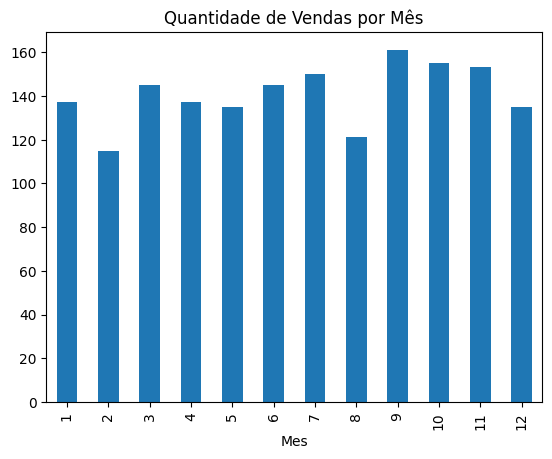

In [26]:
#analisando meses com mais quantidade de venda em ordem cronologica
dataset["Mes"] = dataset["Data_Da_Venda"].dt.month
agrupado = dataset.groupby(["Mes"]).size()

#plotando grafico de coluna
agrupado.plot.bar(title="Quantidade de Vendas por Mês")



<Axes: title={'center': 'Quantidade de Vendas por Mês'}, xlabel='Mes'>

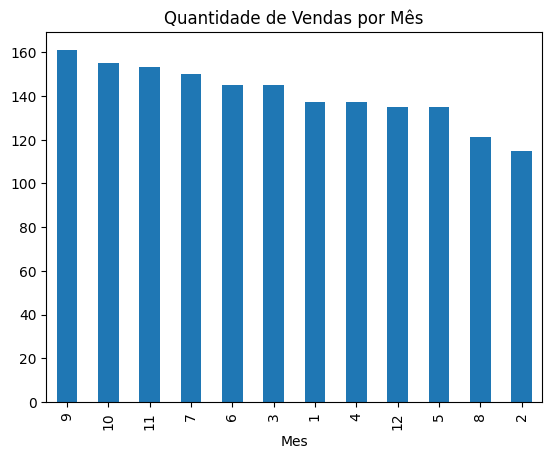

In [27]:
#analisando em numeros meses com maior lucro em ordem de quantidade
ranking_qnt= dataset.groupby(["Mes"]).size().sort_values(ascending=False)
ranking_qnt.plot.bar(title="Quantidade de Vendas por Mês")

<Axes: title={'center': 'Lucro por Mês'}, ylabel='Mes'>

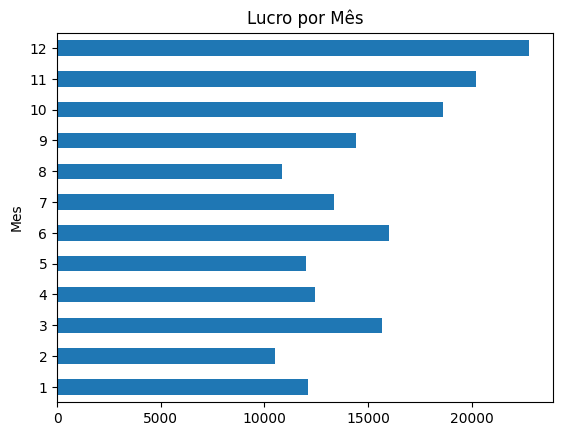

In [28]:
#analisando meses com lucro em ordem cronologica
agrupado = dataset.groupby(["Mes"])["Lucro"].sum()

#plotando grafico de coluna
agrupado.plot.barh(title="Lucro por Mês", )

<Axes: title={'center': 'Lucro por Mês'}, xlabel='Mes'>

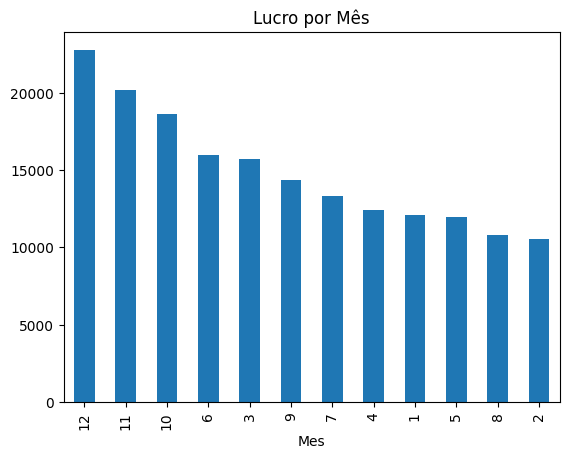

In [29]:
#analisando em numeros meses com maior lucro em ordem de lucro
ranking_lucro = dataset.groupby(["Mes"])["Lucro"].sum().sort_values(ascending=False)

ranking_lucro.plot.bar(title="Lucro por Mês")


##Setor e produto


<Axes: title={'center': 'Quantidade de Vendas por Setor'}>

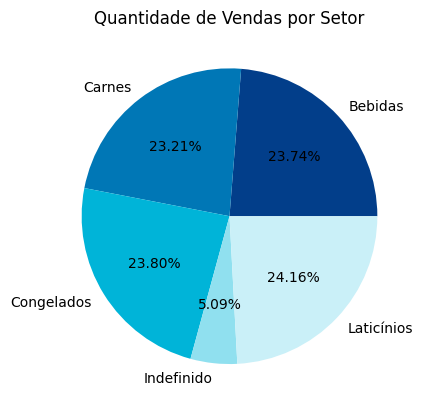

In [30]:
#analisando os setores vendidos
agrupado = dataset.groupby(["Setor"]).size()

#plotando grafico de pizza
cores_escolhidas = ["#023E8A","#0077B6", "#00B4D8", "#90E0EF", "#CAF0F8" ]
agrupado.plot.pie(title="Quantidade de Vendas por Setor", autopct="%.2f%%", colors=cores_escolhidas)

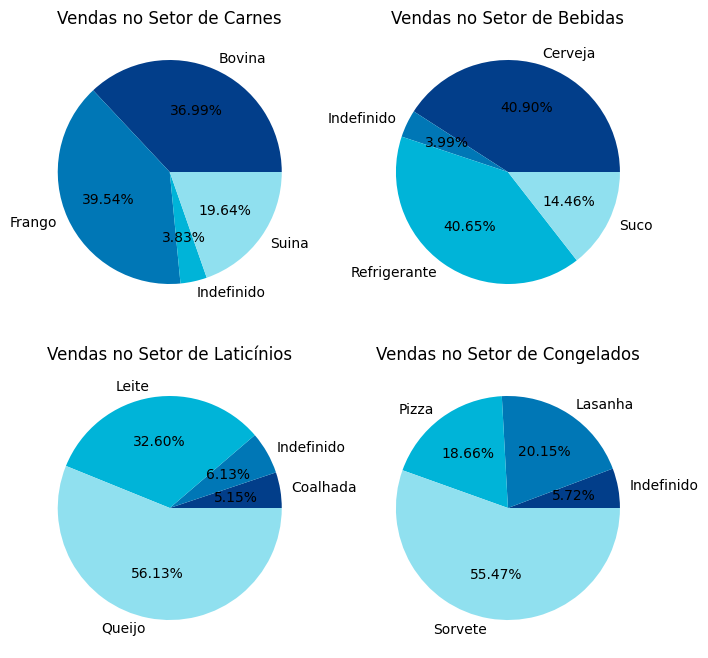

In [31]:
#Analisando os produtos mais escolhidos em cada setor
setor_carne= dataset[dataset["Setor"] == "Carnes"]
g1 = setor_carne.groupby(["Produto"]).size()

setor_bebidas = dataset[dataset["Setor"] == "Bebidas"]
g2 = setor_bebidas.groupby(["Produto"]).size()

setor_laticinios = dataset[dataset["Setor"] == "Laticínios"]
g3 = setor_laticinios.groupby(["Produto"]).size()

setor_congelados = dataset[dataset["Setor"] == "Congelados"]
g4 = setor_congelados.groupby(["Produto"]).size()

#plotando os graficos
plt.figure(figsize=(8, 8))
plt.subplot(221)
g1.plot.pie(title="Vendas no Setor de Carnes",autopct="%.2f%%", colors = cores_escolhidas)
plt.subplot(222)
g2.plot.pie(title="Vendas no Setor de Bebidas",autopct="%.2f%%", colors = cores_escolhidas)
plt.subplot(223)
g3.plot
g3.plot.pie(title="Vendas no Setor de Laticínios",autopct="%.2f%%", colors = cores_escolhidas)
plt.subplot(224)
g4.plot.pie(title="Vendas no Setor de Congelados",autopct="%.2f%%", colors = cores_escolhidas)
plt.show()


##Vendedor

<Axes: title={'center': 'Quantidade de Vendas por Vendedor'}, xlabel='Vendedor'>

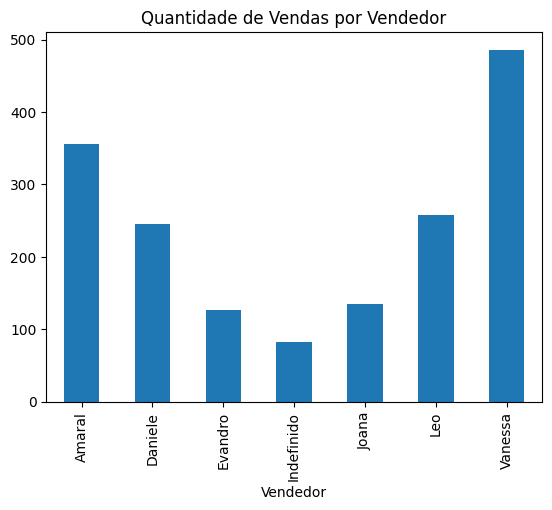

In [32]:
#Analisando quem vendeu mais
agrupado = dataset.groupby(["Vendedor"]).size()

#plotando grafico de coluna
agrupado.plot.bar(title="Quantidade de Vendas por Vendedor")

##Cliente

<Axes: title={'center': 'Quantidade de Vendas por Cliente'}>

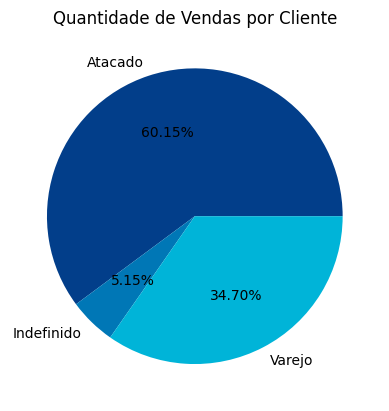

In [33]:
#analisando o tipo de cliente
agrupado = dataset.groupby(["Cliente"]).size()

#Plotando grafico pizza
agrupado.plot.pie(title="Quantidade de Vendas por Cliente", autopct="%.2f%%", colors=cores_escolhidas)

##Estado e Regiao

<Axes: title={'center': 'Quantidade de Vendas por Região'}>

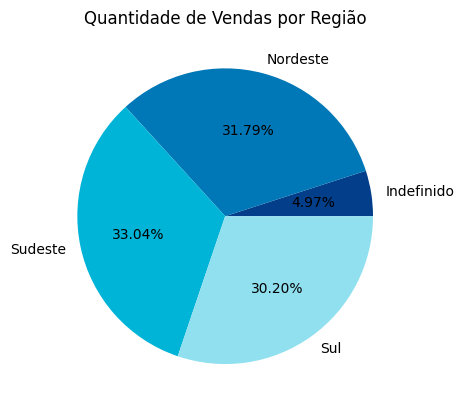

In [34]:
#Analisando os estados
agrupado = dataset.groupby(["Região"]).size()

#plotando grafico de coluna
agrupado.plot.pie(title="Quantidade de Vendas por Região", colors= cores_escolhidas, autopct="%.2f%%")

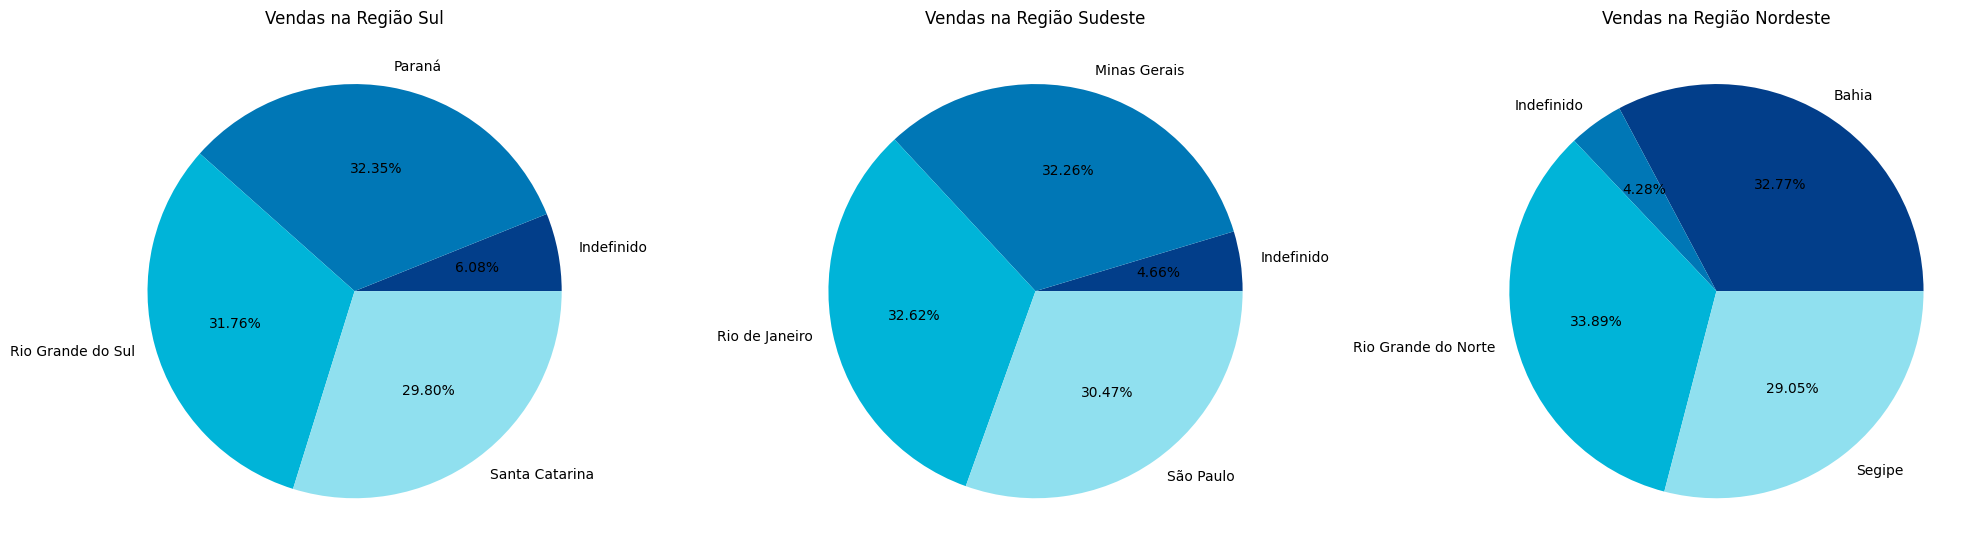

In [35]:
#Analisando os estados mais particpiativos em cada região
regiao_sul = dataset[dataset["Região"] == "Sul"]
g1 = regiao_sul.groupby(["Estado"]).size()

regiao_sudeste = dataset[dataset["Região"] == "Sudeste"]
g2 = regiao_sudeste.groupby(["Estado"]).size()

regiao_nordeste = dataset[dataset["Região"] == "Nordeste"]
g3 = regiao_nordeste.groupby(["Estado"]).size()

#plotando os graficos
plt.figure(figsize=(20, 8))

# Primeiro gráfico — Região Sul
plt.subplot(1, 3, 1)
g1.plot.pie(
    title="Vendas na Região Sul",
    autopct="%.2f%%",
    colors=cores_escolhidas,
    legend=False
)

# Segundo gráfico — Região Sudeste
plt.subplot(1, 3, 2)
g2.plot.pie(
    title="Vendas na Região Sudeste",
    autopct="%.2f%%",
    colors=cores_escolhidas,
    legend=False
)

# Terceiro gráfico — Região Nordeste
plt.subplot(1, 3, 3)
g3.plot.pie(
    title="Vendas na Região Nordeste",
    autopct="%.2f%%",
    colors=cores_escolhidas,
    legend=False
)

# Ajusta o layout e mostra
plt.tight_layout()
plt.show()

## Rendimento por região

<Axes: title={'center': 'Lucro por Região'}, ylabel='Região'>

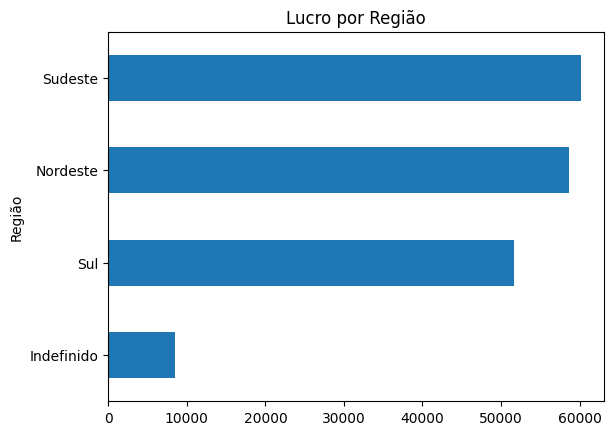

In [36]:
#analisando qual região gera o maior lucro
agrupado = dataset.groupby(["Região"])["Lucro"].sum().sort_values(ascending=True)

#plotando grafico de coluna
agrupado.plot.barh(title="Lucro por Região")

## Desempenho dos vendedor


<Axes: title={'center': 'Lucro por Vendedor'}, xlabel='Vendedor'>

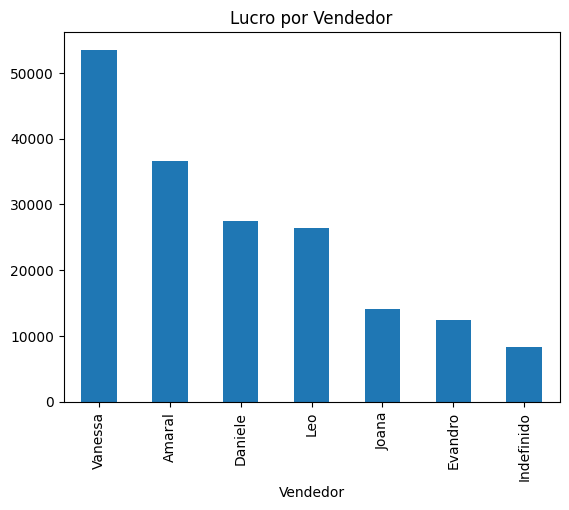

In [37]:
#analisando lucro de cada vendedor
agrupado = dataset.groupby(['Vendedor'])['Lucro'].sum().sort_values(ascending=False)

#plotando grafico de coluna
agrupado.plot.bar(title="Lucro por Vendedor")


## Itens mais consumido em cada setor

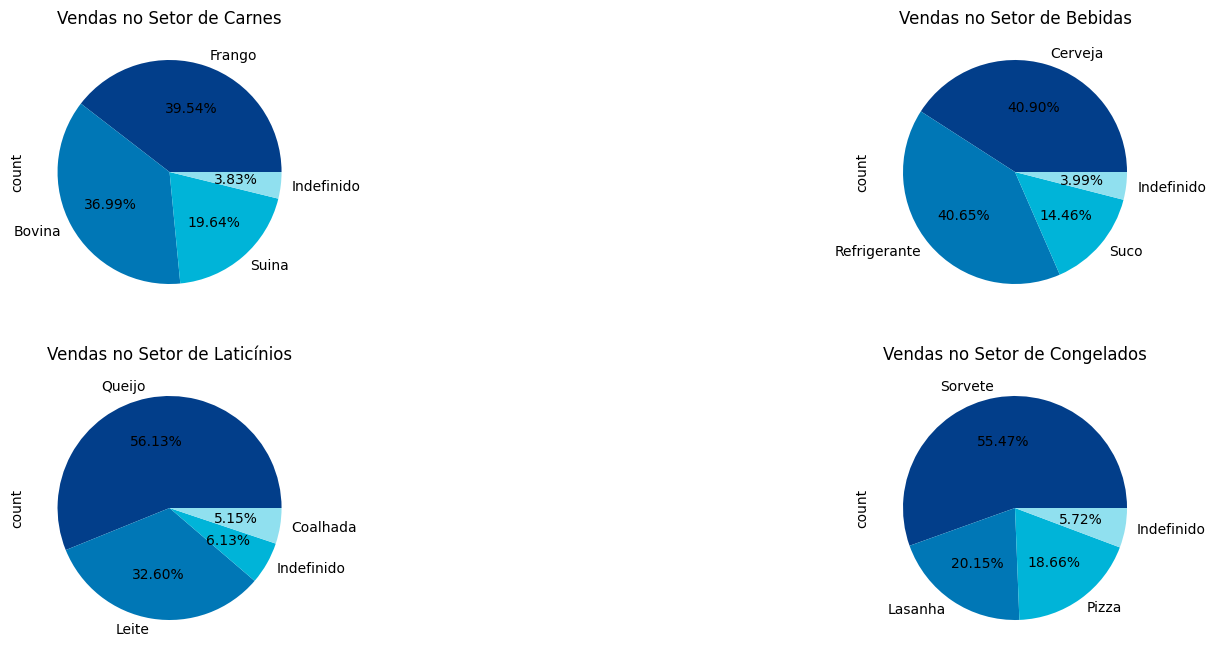

In [38]:
#analisando como cada produto contribui em cada setor
g1= dataset[dataset['Setor'] == 'Carnes'].groupby('Produto')['Produto'].value_counts().sort_values(ascending=False)
g2= dataset[dataset['Setor'] == 'Bebidas'].groupby('Produto')['Produto'].value_counts().sort_values(ascending=False)
g3= dataset[dataset['Setor'] == 'Laticínios'].groupby('Produto')['Produto'].value_counts().sort_values(ascending=False)
g4= dataset[dataset['Setor'] == 'Congelados'].groupby('Produto')['Produto'].value_counts().sort_values(ascending=False)

#plotando os graficos
plt.figure(figsize=(20, 8))
plt.subplot(221)
g1.plot.pie(title="Vendas no Setor de Carnes",autopct="%.2f%%", colors = cores_escolhidas)
plt.subplot(222)
g2.plot.pie(title="Vendas no Setor de Bebidas",autopct="%.2f%%", colors = cores_escolhidas)
plt.subplot(223)
g3.plot
g3.plot.pie(title="Vendas no Setor de Laticínios",autopct="%.2f%%", colors = cores_escolhidas)
plt.subplot(224)
g4.plot.pie(title="Vendas no Setor de Congelados",autopct="%.2f%%", colors = cores_escolhidas)
plt.show()